# Laboratory Exercise 3: K-Nearest Neighbors (KNN) and Logistic Regression on Customer Segmentation Dataset

First few rows of the dataset:
   CustomerID  Age  AnnualIncome  SpendingScore
0           1   22         15000             39
1           2   35         40000             81
2           3   26         30000             77
3           4   40         50000             40
4           5   55        100000              6

Missing values in the dataset:
CustomerID       0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


<Figure size 1000x600 with 0 Axes>

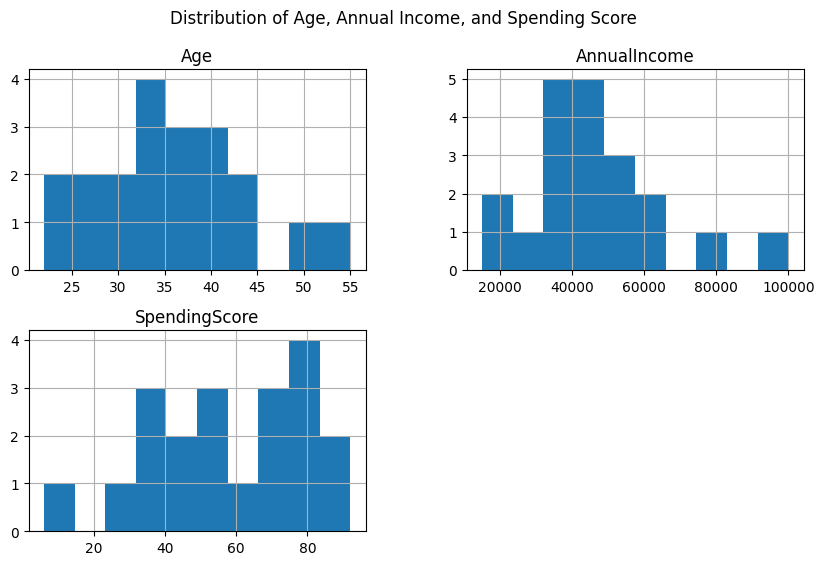


First few rows of the scaled data:
        Age  AnnualIncome  SpendingScore
0 -1.658204     -1.641181      -0.894674
1 -0.096128     -0.300347       1.032316
2 -1.177565     -0.836681       0.848794
3  0.504671      0.235987      -0.848794
4  2.307066      2.917656      -2.408738

Statistics of scaled data:
                Age  AnnualIncome  SpendingScore
count  2.000000e+01  2.000000e+01   2.000000e+01
mean   3.524958e-16 -1.110223e-17   2.775558e-18
std    1.025978e+00  1.025978e+00   1.025978e+00
min   -1.658204e+00 -1.641181e+00  -2.408738e+00
25%   -7.269661e-01 -4.880637e-01  -7.799724e-01
50%   -3.604790e-02 -1.662635e-01  -4.588073e-02
75%    5.347106e-01  3.834786e-01   8.487935e-01
max    2.307066e+00  2.917656e+00   1.537005e+00


In [1]:
#@title # Exercise 1: Data Exploration and Preprocessing

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('customer_segmentation.csv')

print("First few rows of the dataset:")
print(df.head())

print("\nMissing values in the dataset:")
print(df.isnull().sum())

plt.figure(figsize=(10, 6))
df[['Age', 'AnnualIncome', 'SpendingScore']].hist(bins=10, figsize=(10, 6))
plt.suptitle('Distribution of Age, Annual Income, and Spending Score')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Age', 'AnnualIncome', 'SpendingScore']])

df_scaled = pd.DataFrame(scaled_data, columns=['Age', 'AnnualIncome', 'SpendingScore'])

print("\nFirst few rows of the scaled data:")
print(df_scaled.head())

print("\nStatistics of scaled data:")
print(df_scaled.describe())

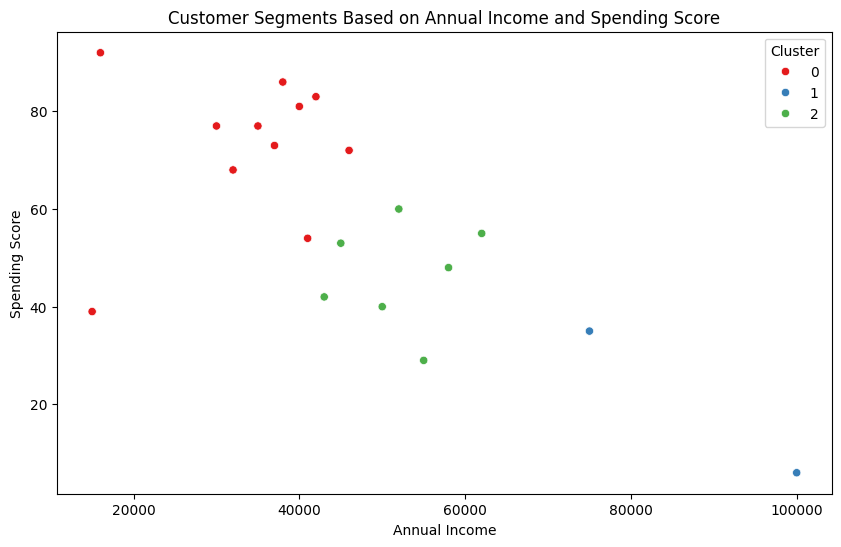

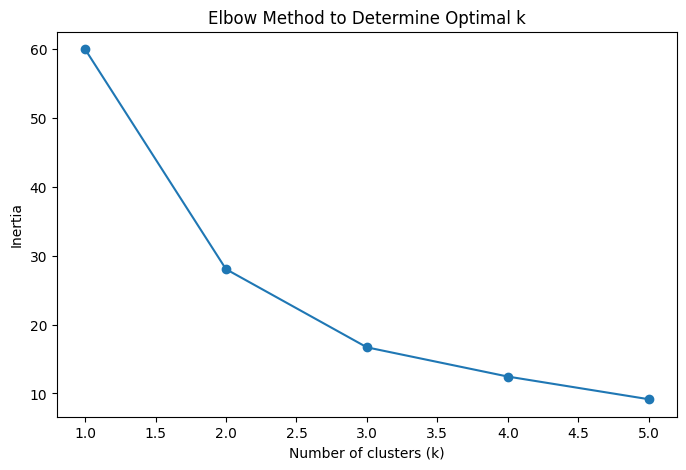

In [2]:
#@title # Exercise 2: Implementing K-Means Clustering

from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='AnnualIncome', y='SpendingScore', hue='Cluster', data=df, palette='Set1')
plt.title('Customer Segments Based on Annual Income and Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='Cluster')
plt.show()

inertia = []
k_values = range(1, 6)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method to Determine Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.show()

Silhouette Scores for different values of k:
For k=2, the silhouette score is 0.431
For k=3, the silhouette score is 0.396
For k=4, the silhouette score is 0.319
For k=5, the silhouette score is 0.339


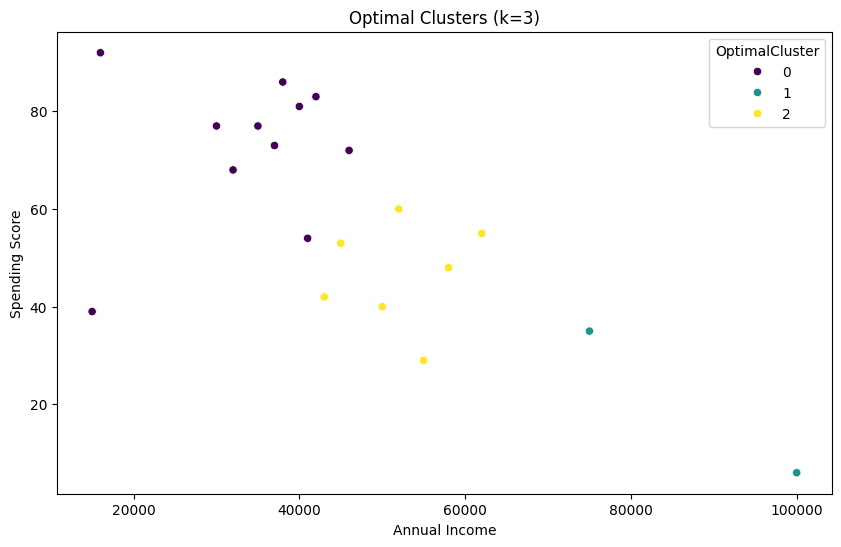


Cluster Summary:
                CustomerID        Age  AnnualIncome  SpendingScore  Cluster
OptimalCluster                                                             
0                 9.272727  30.090909  33818.181818      72.909091      0.0
1                 6.000000  52.500000  87500.000000      20.500000      1.0
2                13.714286  40.000000  52142.857143      46.714286      2.0


In [3]:
#@title # Exercise 3: Model Evaluation

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

print("Silhouette Scores for different values of k:")
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(df_scaled)
    silhouette_avg = silhouette_score(df_scaled, clusters)
    print(f'For k={k}, the silhouette score is {silhouette_avg:.3f}')

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['OptimalCluster'] = kmeans.fit_predict(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='AnnualIncome', y='SpendingScore', hue='OptimalCluster', data=df, palette='viridis')
plt.title(f'Optimal Clusters (k={optimal_k})')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend(title='OptimalCluster')
plt.savefig('optimal_clusters.png')
plt.show()

cluster_summary = df.groupby('OptimalCluster').mean()
print("\nCluster Summary:")
print(cluster_summary)

In [4]:
#@title # Exercise 4: Interpretation and Reporting
#@markdown # **Cluster Interpretation**
#@markdown -  The cluster analysis consists of three distinct groups: Cluster 0, which has a moderate annual income and high spending scores, and Cluster 1, which has a high annual income and low spending scores, possibly representing affluent customers with conservative spending habits. The second cluster, with an average annual income of $52,143 and a spending score of 46.71, represents customers with moderate income and spending habits. These clusters are categorized based on their income, spending habits, and overall spending habits.


#@markdown # **Data exploration process**
#@markdown - **First few rows of the scaled data:**
#@markdown ```
#@markdown           Age      AnnualIncome   SpendingScore
#@markdown 0   -1.658204     -1.641181       -0.894674
#@markdown 1   -0.096128     -0.300347        1.032316
#@markdown 2   -1.177565     -0.836681        0.848794
#@markdown 3    0.504671      0.235987       -0.848794
#@markdown 4    2.307066      2.917656       -2.408738
#@markdown ```

#@markdown - **Statistics of scaled data:**
#@markdown ```
#@markdown                 Age        AnnualIncome   SpendingScore
#@markdown count    2.000000e+01    2.000000e+01    2.000000e+01
#@markdown mean     3.524958e-16   -1.110223e-17    2.775558e-18
#@markdown std      1.025978e+00    1.025978e+00    1.025978e+00
#@markdown min     -1.658204e+00   -1.641181e+00   -2.408738e+00
#@markdown 25%     -7.269661e-01   -4.880637e-01   -7.799724e-01
#@markdown 50%     -3.604790e-02   -1.662635e-01   -4.588073e-02
#@markdown 75%      5.347106e-01    3.834786e-01    8.487935e-01
#@markdown max      2.307066e+00    2.917656e+00    1.537005e+00
#@markdown ```

#@markdown # **Silhouette Scores of k's:**
#@markdown - For k=2, Silhouette score = 0.431
#@markdown - For k=3, Silhouette score = 0.396
#@markdown - For k=4, Silhouette score = 0.319
#@markdown - For k=5, Silhouette score = 0.339

#@markdown # **Cluster Analysis**
#@markdown - The analysis of clusters reveals that younger customers with moderate incomes and higher spending scores are value-driven, while older customers with high incomes but lower spending scores may be selective or conservative. Middle-aged customers with moderate income and spending scores may represent a balanced customer profile, with neither extreme spending behavior nor high earnings. These findings suggest that customers' purchasing habits can vary depending on their income and spending habits.